In [ ]:
# 既にインストールされていれば不要
!pip install quri-parts
!pip install "quri-parts[qulacs]"

In [ ]:
# 既にインストールされていれば不要
!pip install "quri-parts[pyscf,openfermion]"

In [3]:
import numpy as np
from pyscf import gto, scf
from quri_parts.pyscf.mol import get_spin_mo_integrals_from_mole
from quri_parts.openfermion.mol import get_qubit_mapped_hamiltonian
from quri_parts.chem.mol import cas

# 水分子の結合距離(単位はオングストローム)と結合角
bond = 0.96; angle = 104.5
# 水分子の幾何構造
x = bond * np.cos(np.radians(angle)); y = bond * np.sin(np.radians(angle))
geometry = [ ('O', (0, 0, 0)), ('H', (bond, 0, 0)), ('H', (x, y, 0))]
# ハートリー・フォック計算を行う
mole = gto.M(
    atom=geometry,
    basis="sto-3g",
    spin=0, charge=0,
)
mf = scf.RHF(mole).run(verbose=0)

# ハミルトニアンの構成
n_active_ele = 6 # 活性空間内の電子数
n_active_orb = 5 # 活性空間内の分子軌道数
n_qubits = 2 * n_active_orb # 量子ビット数は活性空間内の分子軌道の数の2 倍
jw_ham, jw_mapping = get_qubit_mapped_hamiltonian(
    *get_spin_mo_integrals_from_mole(
        mole, mf.mo_coeff,cas(n_active_ele,n_active_orb)
    )
)

In [4]:
from quri_parts.core.operator import get_sparse_matrix
from scipy.sparse.linalg import eigsh

e_hf = mf.e_tot # ハートリー・フォックエネルギー
print("ハートリー・フォックエネルギー:", e_hf)
ham_matrix = get_sparse_matrix(jw_ham)
eigvals, eigvecs = eigsh(ham_matrix, k=2, which="SA") # 最小固有値を2 つ求める
e_fci = eigvals[0]
print("厳密な基底状態エネルギー:", e_fci)

ハートリー・フォックエネルギー: -74.96331905254007
厳密な基底状態エネルギー: -74.99738460045658


In [5]:
from quri_parts.algo.ansatz import SymmetryPreservingReal
from quri_parts.core.state import apply_circuit, quantum_state

# 変分量子回路
reps = 6
ansatz_circuit = SymmetryPreservingReal(qubit_count=n_qubits, reps=reps)
print("パラメータ数:", ansatz_circuit.parameter_count)

# "0...01...1"という文字列を作り, 二進数と解釈した整数に変換
hf_state_bit = "0" * (n_qubits - n_active_ele) + "1" * n_active_ele
print("string:", hf_state_bit)
hf_state_bit = int(hf_state_bit, 2)
print("int:", hf_state_bit)

# 変分量子状態
parametric_state = quantum_state(n_qubits, bits=hf_state_bit, circuit=ansatz_circuit)

パラメータ数: 54
string: 0000111111
int: 63


In [6]:
from quri_parts.qulacs.estimator import create_qulacs_vector_estimator

estimator = create_qulacs_vector_estimator()
def cost(theta_list: list[float]) -> float:
    state = parametric_state.bind_parameters(theta_list)
    return estimator(jw_ham, state).value.real

theta_history = []; cost_history = []

def my_callback(theta_list):
    theta_history.append(theta_list)
    cost_history.append(cost(theta_list))

以下のVQEの最適化結果は、書籍版と若干異なります。

In [7]:
%%time
from scipy.optimize import minimize

# 初期パラメータをランダムに設定
rng = np.random.default_rng(42) # 乱数生成器の初期化
theta_0 = 0.2 * np.pi * rng.random(ansatz_circuit.parameter_count)

theta_history.append(theta_0)
cost_history.append(cost(theta_0))

result = minimize(
    cost, theta_0, method="BFGS",
    options={"gtol": 1e-4, "disp": True, "maxiter": 1000},
    callback=my_callback,
)

print("最適化後のエネルギー:", result.fun)
print("厳密な基底状態エネルギーとの差:", result.fun - e_fci)

Optimization terminated successfully.
         Current function value: -74.991772
         Iterations: 428
         Function evaluations: 23870
         Gradient evaluations: 434
最適化後のエネルギー: -74.99177227830782
厳密な基底状態エネルギーとの差: 0.0056123221487638375
CPU times: user 4min 45s, sys: 4.53 s, total: 4min 49s
Wall time: 2min 55s


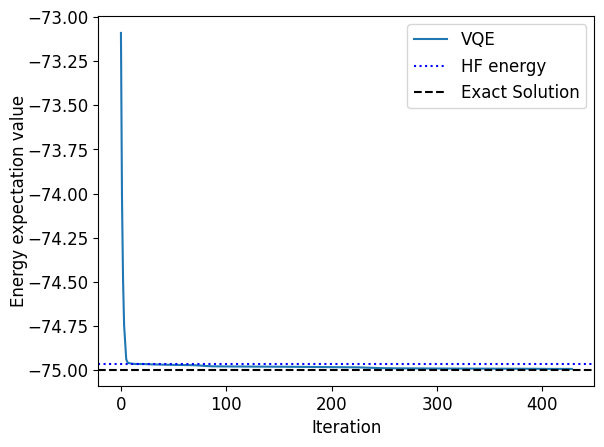

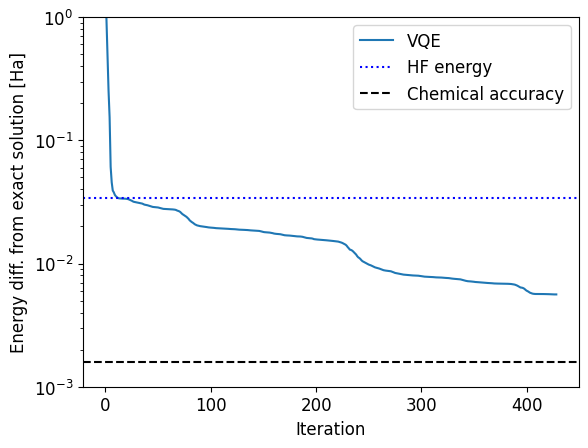

In [8]:
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 12
plt.plot(cost_history, "-", label="VQE")
plt.axhline(e_hf, color="b", linestyle=":", label="HF energy")
plt.axhline(e_fci, color="k", linestyle="--", label="Exact Solution")
plt.xlabel("Iteration")
plt.ylabel("Energy expectation value", labelpad=-0.5)
plt.legend()
plt.show()

plt.plot(np.array(cost_history) - e_fci, "-", label="VQE")
plt.axhline(e_hf-e_fci, color="b", linestyle=":", label="HF energy",)
plt.axhline(1.6e-3, color="k", linestyle="--", label="Chemical accuracy",)
plt.xlabel("Iteration")
plt.ylabel("Energy diff. from exact solution [Ha]")
plt.yscale("log")
plt.ylim(1e-3, 1)
plt.legend()
plt.show()

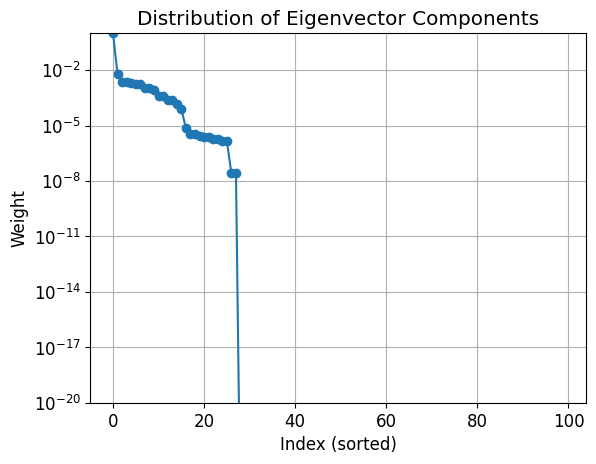

In [9]:
dim_sector = 100
# 厳密な基底状態の波動関数を用いて, 各成分の重みを計算
vec_fci = eigvecs[:,0]
weights = np.abs(vec_fci) ** 2
# 大きい順に並び替え
sorted_weights = np.sort(weights)[::-1]

# 可視化
plt.plot(sorted_weights[:dim_sector], "o-")
plt.xlabel("Index (sorted)")
plt.ylabel("Weight")
plt.yscale("log")
plt.ylim(1e-20, 1)
plt.title("Distribution of Eigenvector Components")
plt.grid(True)
plt.show()

In [10]:
argsort_weights = np.argsort(weights)[::-1]
for i in range(10):
    bit = argsort_weights[i]
    print(f"Bit: {bit:010b}, weight: {weights[bit]:.4e}")

Bit: 0000111111, weight: 9.7937e-01
Bit: 1100111100, weight: 5.8418e-03
Bit: 0110110110, weight: 2.3739e-03
Bit: 1001111001, weight: 2.3739e-03
Bit: 1100110011, weight: 1.9964e-03
Bit: 0011110011, weight: 1.8093e-03
Bit: 0011111100, weight: 1.7257e-03
Bit: 1001110110, weight: 1.0771e-03
Bit: 0110111001, weight: 1.0771e-03
Bit: 0011001111, weight: 7.8714e-04


VQEの最適化結果が若干異なるため、以下の計算結果も書籍版と若干異なります。

In [11]:
from quri_parts.qulacs.sampler import create_qulacs_vector_state_sampler

sampler = create_qulacs_vector_state_sampler()

# VQE で最適化された状態
state = parametric_state.bind_parameters(theta_history[-1])
# サンプリングの実行
total_shots = 10**6 # サンプリングの総数
sample_result = sampler(state, total_shots)
sorted_sample_result = sorted( # サンプル結果をソート
    sample_result.items(), key=lambda x: x[1], reverse=True
)
print(len(sorted_sample_result), "distinct samples found.")
for bit, count in sorted_sample_result[:10]: # 上位10 個のサンプルを表示
    print(f"{bit=:010b}, {count=:d}")

119 distinct samples found.
bit=0000111111, count=983463
bit=1100111100, count=5090
bit=0011111100, count=1779
bit=1100110011, count=1707
bit=0110110110, count=1491
bit=1001111001, count=1235
bit=1001110110, count=1070
bit=0110111001, count=1025
bit=0011110011, count=534
bit=0011101110, count=222


※書籍版のimport文ではエラーになるため、括弧を追加しています。

In [12]:
# <i_a|H|i_b>を計算するためのquri-parts内の関数
from quri_parts.core.operator import (transition_amp_comp_basis,
transition_amp_representation)

# 成分計算を効率的に行うための前処理
h_transition_amp_repr = transition_amp_representation(jw_ham)

# 有効ハミルトニアンの計算
def qsci(h_transition_amp_repr, sorted_sample_result, R_trunc):
    if R_trunc > len(sorted_sample_result):
        raise ValueError("R_trunc must be less than or equal to distinct samples.")
    # 上位R_trunc個のビット列(に対応する整数) を取得
    z = [ v[0] for v in sorted_sample_result[:R_trunc] ]
    # 有効ハミルトニアンを計算
    H_trunc = np.zeros((R_trunc, R_trunc), dtype=np.complex128)
    for i in range(R_trunc):
        for j in range(R_trunc):
            H_trunc[i][j] = transition_amp_comp_basis(h_transition_amp_repr, z[i], z[j])
    eigvalss_QSCI, _ = np.linalg.eigh(H_trunc)
    return eigvalss_QSCI[0] # 最小固有値を返す

In [13]:
for R in [1, 2, 5, 10, 20, 30]:
    e_QSCI = qsci(h_transition_amp_repr, sorted_sample_result, R)
    print("R:", R)
    print("QSCI エネルギー:", e_QSCI)
    print("厳密な基底状態エネルギーとの差:", e_QSCI - e_fci)

R: 1
QSCI エネルギー: -74.96331905254003
厳密な基底状態エネルギーとの差: 0.034065547916554806
R: 2
QSCI エネルギー: -74.97597941244206
厳密な基底状態エネルギーとの差: 0.02140518801452629
R: 5
QSCI エネルギー: -74.98555419277517
厳密な基底状態エネルギーとの差: 0.011830407681415522
R: 10
QSCI エネルギー: -74.99468328538794
厳密な基底状態エネルギーとの差: 0.0027013150686485687
R: 20
QSCI エネルギー: -74.99599298554935
厳密な基底状態エネルギーとの差: 0.0013916149072343842
R: 30
QSCI エネルギー: -74.9961914907709
厳密な基底状態エネルギーとの差: 0.0011931096856869772


In [14]:
from quri_parts.core.estimator.sampling import create_sampling_estimator
from quri_parts.core.measurement import bitwise_commuting_pauli_measurement
from quri_parts.core.sampling.shots_allocator import create_proportional_shots_allocator
from quri_parts.qulacs.sampler import create_qulacs_vector_concurrent_sampler

concurrent_sampler = create_qulacs_vector_concurrent_sampler()
measurement_factory = bitwise_commuting_pauli_measurement
shots_allocator = create_proportional_shots_allocator()

sampling_estimator = create_sampling_estimator(
total_shots, concurrent_sampler, measurement_factory, shots_allocator
)

est_by_sampling_list = []
for _ in range(10):
    estimate = sampling_estimator(jw_ham, state)
    est_by_sampling_list.append(estimate.value.real)

est_by_sampling_list = np.array(est_by_sampling_list)
print("平均:", est_by_sampling_list.mean())
print("標準偏差:", est_by_sampling_list.std())

平均: -74.99170570823023
標準偏差: 0.0012757091906276552
